<a href="https://colab.research.google.com/github/TaimoorAbdullah/Practicing-github/blob/main/Project10(LogisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%cd /content/drive/MyDrive/Course Material/Supervised Machine Learning/Logistic Regression

/content/drive/MyDrive/Course Material/Supervised Machine Learning/Logistic Regression


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data  =  pd.read_csv('titanic_train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data.isnull().any()

,0
Survived,False
Pclass,False
Sex,False
Age,True
SibSp,False
Parch,False
Fare,False
Cabin,True
Embarked,True


In [ ]:
data.Age.fillna(data.Age.mean(),inplace =  True)

/tmp/ipykernel_554/685231950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Age.fillna(data.Age.mean(),inplace =  True)


In [ ]:
data.isnull().any()

,0
Survived,False
Pclass,False
Sex,False
Age,False
SibSp,False
Parch,False
Fare,False
Cabin,True
Embarked,True


In [ ]:
data.Embarked.dropna()

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [ ]:
data.Survived.value_counts()

,count
Survived,
0,549
1,342


In [ ]:
data.drop(['PassengerId','Ticket','Name'],axis = 1, inplace  =  True)

In [ ]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.000000,1,0,7.2500,NaN,S
1,1,1,female,38.000000,1,0,71.2833,C85,C
2,1,3,female,26.000000,0,0,7.9250,NaN,S
3,1,1,female,35.000000,1,0,53.1000,C123,S
4,0,3,male,35.000000,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,NaN,S
887,1,1,female,19.000000,0,0,30.0000,B42,S
888,0,3,female,29.699118,1,2,23.4500,NaN,S
889,1,1,male,26.000000,0,0,30.0000,C148,C


In [ ]:
dummies_1  =  pd.get_dummies(data['Sex'])
dummies_2  =pd.get_dummies(data['Embarked'])

In [ ]:
data_1  =  pd.concat([data,dummies_1,dummies_2],axis = 1)

In [ ]:
data_1

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,female,male,C,Q,S
0,0,3,male,22.000000,1,0,7.2500,NaN,S,False,True,False,False,True
1,1,1,female,38.000000,1,0,71.2833,C85,C,True,False,True,False,False
2,1,3,female,26.000000,0,0,7.9250,NaN,S,True,False,False,False,True
3,1,1,female,35.000000,1,0,53.1000,C123,S,True,False,False,False,True
4,0,3,male,35.000000,0,0,8.0500,NaN,S,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,NaN,S,False,True,False,False,True
887,1,1,female,19.000000,0,0,30.0000,B42,S,True,False,False,False,True
888,0,3,female,29.699118,1,2,23.4500,NaN,S,True,False,False,False,True
889,1,1,male,26.000000,0,0,30.0000,C148,C,False,True,True,False,False


In [ ]:
data_1.drop(['Sex','Embarked','Cabin'],axis = 1,inplace  =  True)


In [ ]:
data_1.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


In [ ]:
x = data_1.drop(['Survived'],axis = 1).values
y = data_1['Survived'].values
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression

In [ ]:
x_train,x_test,y_train,y_test  = train_test_split(x,y,test_size  =  0.2,random_state =  42)

In [ ]:
lr   =LogisticRegression()
lr.fit(x_train,y_train)
prediction = lr.predict_proba(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
prediction.round(3)

array([[0.881, 0.119],
       [0.786, 0.214],
       [0.867, 0.133],
       [0.127, 0.873],
       [0.24 , 0.76 ],
       [0.075, 0.925],
       [0.329, 0.671],
       [0.907, 0.093],
       [0.253, 0.747],
       [0.091, 0.909],
       [0.679, 0.321],
       [0.926, 0.074],
       [0.597, 0.403],
       [0.838, 0.162],
       [0.807, 0.193],
       [0.073, 0.927],
       [0.708, 0.292],
       [0.328, 0.672],
       [0.766, 0.234],
       [0.68 , 0.32 ],
       [0.879, 0.121],
       [0.616, 0.384],
       [0.377, 0.623],
       [0.867, 0.133],
       [0.893, 0.107],
       [0.931, 0.069],
       [0.531, 0.469],
       [0.785, 0.215],
       [0.92 , 0.08 ],
       [0.39 , 0.61 ],
       [0.864, 0.136],
       [0.334, 0.666],
       [0.46 , 0.54 ],
       [0.382, 0.618],
       [0.861, 0.139],
       [0.859, 0.141],
       [0.572, 0.428],
       [0.329, 0.671],
       [0.059, 0.941],
       [0.895, 0.105],
       [0.801, 0.199],
       [0.916, 0.084],
       [0.895, 0.105],
       [0.8

In [ ]:
pred  =  lr.predict(x_test)
pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [ ]:
accuracy  =  sum(y_test  ==pred)/len(y_test)
accuracy

np.float64(0.8044692737430168)

In [ ]:
Accuracy  =  accuracy_score(y_test,pred)
Accuracy

0.8044692737430168

In [ ]:
precision  =  precision_score(y_test,pred)
precision

0.782608695652174

In [ ]:
recall =  recall_score(y_test,pred)
recall

0.7297297297297297

In [ ]:
f1  =  f1_score(y_test,pred)
f1

0.7552447552447552

In [ ]:
confusionmatrix  =  confusion_matrix(y_test,pred)
confusionmatrix

array([[90, 15],
       [20, 54]])

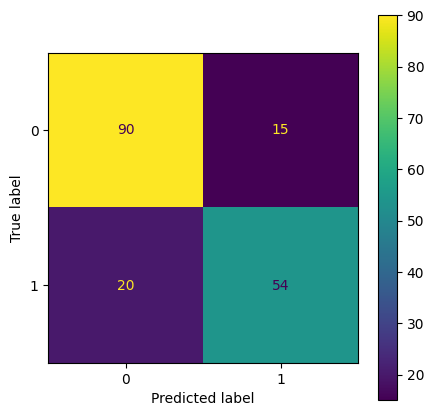

In [ ]:
fig,axes = plt.subplots(1,1,figsize = (5,5))
confusion_m_d = ConfusionMatrixDisplay(confusion_matrix  =  confusionmatrix,display_labels = data_1.Survived.unique())
confusion_m_d.plot(ax  =  axes)